In [130]:
import numpy as np
import matplotlib.pyplot as plt

# Gradient descent

In [131]:
# Assume x.shape = (2,)
def f(x):
    x1 = x[0]
    x2 = x[1]
    return 10 * (x1-1)**2 + (x2+1)**2
    
def grad_f(x):
    x1 = x[0]
    x2 = x[1]
    return  np.array([ 20 * (x1-1), 2 * (x2+1)])

## Stupid GD

In [132]:
# (stupid) GRADIENT DESCENT

def GD( f, 
        grad_f, 
        x0, alpha, 
        maxit=1000, 
        tolf=1e-6, 
        tolx=1e-6
    ):

    for k in range(maxit):
        x = x0 - alpha * grad_f(x0)
        x0 = x
    return x, k

In [133]:
x0 = np.zeros((2,))
alpha = 0.01 # correct
# alpha = 0.1 # to high --> wrong result [0,-1]
# alpha = 0.5 # too high --> diverges

x_sol = GD(f, grad_f, x0, alpha)
print(x_sol)

(array([ 1., -1.]), 999)


## Adding stopping criteria

In [134]:
# (stupid + stopping criteria) GRADIENT DESCENT

def GD( f, 
        grad_f, 
        x0, 
        alpha, 
        maxit=1000, 
        tolf=1e-6, 
        tolx=1e-6
    ):

    x_prec = x0
    for k in range(maxit):
        x = x_prec - alpha * grad_f(x_prec)
        
        # Stopping criteria
        criteria_1 = np.linalg.norm(grad_f(x)) < tolf * np.linalg.norm(grad_f(x0))
        criteria_2 = np.linalg.norm(x - x_prec) < tolx * np.linalg.norm(x0)
        if criteria_1 or criteria_2 : break
        
        x_prec = x
    return x, k

In [135]:
x0 = np.zeros((2,))
alpha = 0.01 # correct
# alpha = 0.1 # to high --> wrong result [0,-1]
# alpha = 0.5 # too high --> diverges

x_sol = GD(f, grad_f, x0, alpha)
print(x_sol)

(array([ 1.        , -0.99999003]), 569)


## Adding plotting infos

In [136]:
# (stupid + stopping criteria + infos) GRADIENT DESCENT

def GD( f, 
        grad_f, 
        x0, 
        alpha, 
        maxit=1000, 
        tolf=1e-6, 
        tolx=1e-6
    ):

    # Initialize the infos
    f_val = np.zeros((maxit+1,))
    grad_norm = np.zeros((maxit+1,))

    # Update
    x_prec = x0
    f_val[0] = f(x0)
    grad_norm[0] = np.linalg.norm(grad_f(x0))
    
    for k in range(maxit):
        
        x = x_prec - alpha * grad_f(x_prec)
        
        # Update
        f_val[k+1] = f(x)
        grad_norm[k+1] = np.linalg.norm(grad_f(x))
        
        # Stopping criteria
        criteria_1 = np.linalg.norm(grad_f(x)) < tolf * np.linalg.norm(grad_f(x0))
        criteria_2 = np.linalg.norm(x - x_prec) < tolx * np.linalg.norm(x0)
        if criteria_1 or criteria_2 : break
        
        x_prec = x
        
    # # Cutting off exceeding variables
    # f_val = f_val[k+1:]
    # grad_norm = grad_norm[k+1:]
    
    return x, k, f_val, grad_norm

 Otained solution: [ 1.         -0.99999003]
 Number of iterations : 569


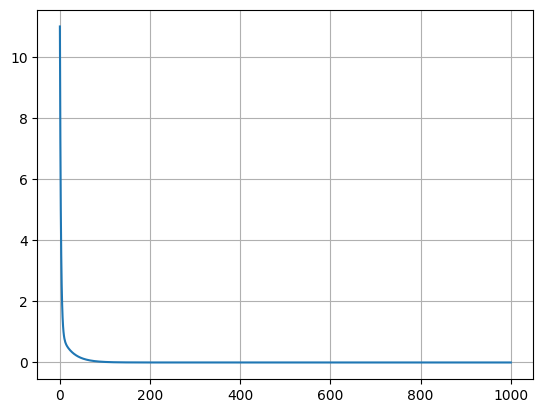

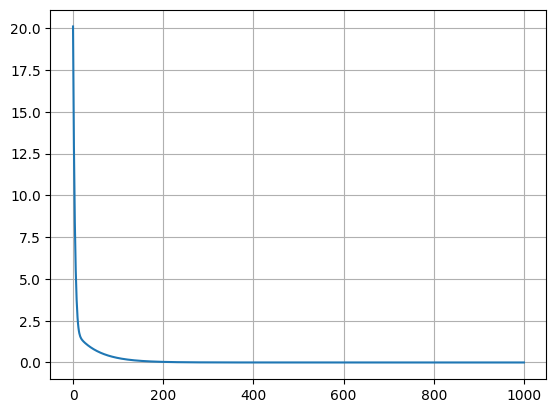

In [137]:
x0 = np.zeros((2,))
alpha = 0.01 # correct
# alpha = 0.1 # to high --> wrong result [0,-1]
# alpha = 0.5 # too high --> diverges

x_sol, num_ierations, f_val, grad_norm = GD(f, grad_f, x0, alpha)
print(f" Otained solution: {x_sol}")
print(f" Number of iterations : {num_ierations}")

plt.plot(f_val)
plt.grid()
plt.show()

plt.plot(grad_norm)
plt.grid()
plt.show()


## Backtracking version of GD

In [138]:
def backtracking(f, grad_f, x):
    """
    This function is a simple implementation of the backtracking algorithm for
    the GD (Gradient Descent) method.
    
    f: function. The function that we want to optimize.
    grad_f: function. The gradient of f(x).
    x: ndarray. The actual iterate x_k.
    """
    alpha = 1
    c = 0.8
    tau = 0.25
    
    while f(x - alpha * grad_f(x)) > f(x) - c * alpha * np.linalg.norm(grad_f(x), 2) ** 2:
        alpha = tau * alpha
    return alpha

In [139]:
# (stupid + stopping criteria + infos) GRADIENT DESCENT

def GD_backtracking( f, 
        grad_f, 
        x0, 
        maxit=1000, 
        tolf=1e-6, 
        tolx=1e-6
    ):

    # Initialize the infos
    f_val = np.zeros((maxit+1,))
    grad_norm = np.zeros((maxit+1,))

    # Update
    x_prec = x0
    f_val[0] = f(x0)
    grad_norm[0] = np.linalg.norm(grad_f(x0))
    
    for k in range(maxit):
        
        alpha_k = backtracking(f, grad_f, x_prec)
        x = x_prec - alpha_k * grad_f(x_prec)
        
        # Update
        f_val[k+1] = f(x)
        grad_norm[k+1] = np.linalg.norm(grad_f(x))
        
        # Stopping criteria
        criteria_1 = np.linalg.norm(grad_f(x)) < tolf * np.linalg.norm(grad_f(x0))
        criteria_2 = np.linalg.norm(x - x_prec) < tolx * np.linalg.norm(x0)
        if criteria_1 or criteria_2 : break
        
        x_prec = x
        
    # # Cutting off exceeding variables (not useful if you want to see differences in plot)
    # f_val = f_val[k+1:]
    # grad_norm = grad_norm[k+1:]
    
    return x, k, f_val, grad_norm

 Otained solution: [ 1.         -0.99999003] vs [ 1.         -0.99999116]
 Number of iterations : 569 vs 93


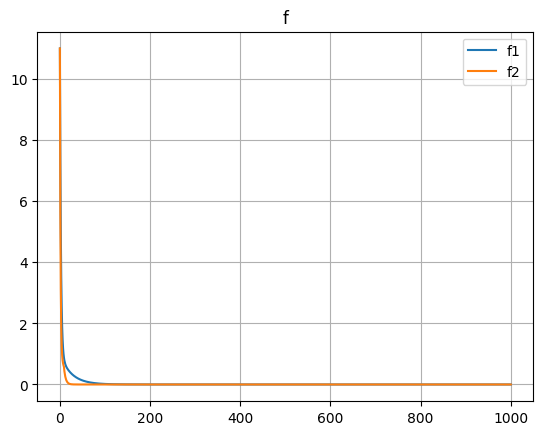

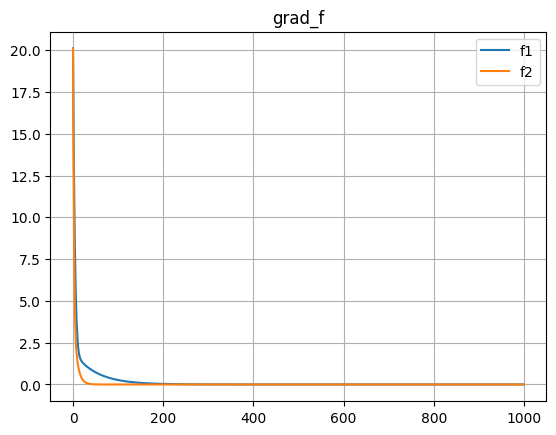

In [140]:
x0 = np.zeros((2,))
alpha = 0.01 # correct

x_sol, num_ierations, f_val, grad_norm = GD(f, grad_f, x0, alpha)
x_sol_backtrack, num_ierations_backtrack, f_val_backtrack, grad_norm_backtrack = GD_backtracking(f, grad_f, x0)

print(f" Otained solution: {x_sol} vs {x_sol_backtrack}")
print(f" Number of iterations : {num_ierations} vs {num_ierations_backtrack}")

plt.plot(f_val)
plt.plot(f_val_backtrack)
plt.legend(["f1", "f2"])
plt.title("f")
plt.grid()
plt.show()

plt.plot(grad_norm)
plt.plot(grad_norm_backtrack)
plt.legend(["f1", "f2"])
plt.title("grad_f")
plt.grid()
plt.show()